# Cross-Asset Risk Analytics

The objective of this notebook is to analyse the risk and return profile of the selected asset universe.

This notebook uses the cleaned price and return datasets generated by the Market Data Pipeline and computes formal risk metrics such as annualized return, volatility, CAGR, maximum drawdown, Sharpe ratio, Sortino ratio, Value at Risk and Conditional Value at Risk.

The goal is to move from descriptive data exploration to quantitative decision analysis.

In [4]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../src/quant_risk_lab")

from quant_risk_lab.risk_metrics import (
    load_prices,
    load_returns,
    compute_annualized_return,
    compute_annualized_volatility,
    compute_cagr,
    compute_cumulative_returns,
    compute_drawdowns,
    compute_max_drawdown,
    compute_sharpe_ratio,
    compute_sortino_ratio,
    compute_historical_var,
    compute_historical_cvar,
    build_risk_summary,
)

## 1. Load Data

We first load the cleaned adjusted close prices and the daily simple returns generated in the previous phase.

In [5]:
prices = load_prices()

prices.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-02,24.192608,114.080002,46.066795,39.681755,0.482423,169.687820,92.659340,57.145554
2015-01-05,23.511061,115.800003,44.636646,39.316833,0.474275,166.623322,94.114830,55.581932
2015-01-06,23.513271,117.120003,43.479256,38.739777,0.459896,165.053909,95.810509,55.286461
2015-01-07,23.842979,116.430000,43.545612,39.231972,0.458697,167.110718,95.621277,55.846642
2015-01-08,24.759079,115.940002,44.518688,40.386112,0.475952,170.076065,94.355003,56.776207


In [6]:
returns = load_returns()

returns.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-05,-0.028172,0.015077,-0.031045,-0.009196,-0.016891,-0.018060,0.015708,-0.027362
2015-01-06,0.000094,0.011399,-0.025929,-0.014677,-0.030318,-0.009419,0.018017,-0.005316
2015-01-07,0.014022,-0.005891,0.001526,0.012705,-0.002606,0.012461,-0.001975,0.010132
2015-01-08,0.038422,-0.004209,0.022346,0.029418,0.037617,0.017745,-0.013243,0.016645
2015-01-09,0.001073,0.011385,-0.017387,-0.008405,0.004028,-0.008013,0.010952,-0.001410


In [7]:
prices.shape, returns.shape

((2905, 8), (2904, 8))

## 2. Risk Summary Table

The following table summarizes the main risk and return metrics for each asset.

In [8]:
risk_summary = build_risk_summary(prices, returns)

risk_summary

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
AAPL,0.265841,0.251007,0.287301,-0.385159,0.855689,1.183934,0.027139,0.041145
GLD,0.115454,0.107596,0.160854,-0.264045,0.593420,0.797753,0.015542,0.023489
JPM,0.212380,0.191829,0.270027,-0.436265,0.712445,0.969313,0.025253,0.038434
MSFT,0.233564,0.216411,0.272416,-0.371485,0.783962,1.077831,0.026588,0.038797
NVDA,0.642515,0.691104,0.482332,-0.663351,1.290635,1.913406,0.044188,0.064877
SPY,0.143175,0.135702,0.176204,-0.337173,0.699046,0.857827,0.016585,0.026758
TLT,0.001595,-0.009308,0.148169,-0.483512,-0.124217,-0.187425,0.014829,0.020261
XOM,0.125542,0.091347,0.275223,-0.613425,0.383477,0.539056,0.025969,0.039559


In [9]:
risk_summary_percent = risk_summary.copy()

percentage_columns = [
    "Annualized Return",
    "CAGR",
    "Annualized Volatility",
    "Maximum Drawdown",
    "Historical VaR 95%",
    "Historical CVaR 95%",
]

risk_summary_percent[percentage_columns] = risk_summary_percent[percentage_columns] * 100

risk_summary_percent

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
AAPL,26.584064,25.100739,28.730141,-38.515898,0.855689,1.183934,2.713899,4.114490
GLD,11.545412,10.759648,16.085413,-26.404518,0.593420,0.797753,1.554250,2.348925
JPM,21.237954,19.182912,27.002708,-43.626497,0.712445,0.969313,2.525291,3.843430
MSFT,23.356374,21.641086,27.241577,-37.148487,0.783962,1.077831,2.658800,3.879669
NVDA,64.251494,69.110430,48.233224,-66.335091,1.290635,1.913406,4.418787,6.487712
SPY,14.317502,13.570239,17.620448,-33.717271,0.699046,0.857827,1.658457,2.675814
TLT,0.159488,-0.930777,14.816928,-48.351153,-0.124217,-0.187425,1.482899,2.026091
XOM,12.554181,9.134704,27.522316,-61.342483,0.383477,0.539056,2.596882,3.955903


## 3. Annualized Return

Annualized return estimates the average yearly return based on daily returns. It is computed as the mean daily return multiplied by the number of trading days in a year.

This metric gives a first approximation of return, but it does not fully capture compounding. For that reason, CAGR is also analysed.

In [10]:
annualized_return = compute_annualized_return(returns).sort_values(ascending=False)

annualized_return

NVDA    0.642515
AAPL    0.265841
MSFT    0.233564
JPM     0.212380
SPY     0.143175
XOM     0.125542
GLD     0.115454
TLT     0.001595
dtype: float64

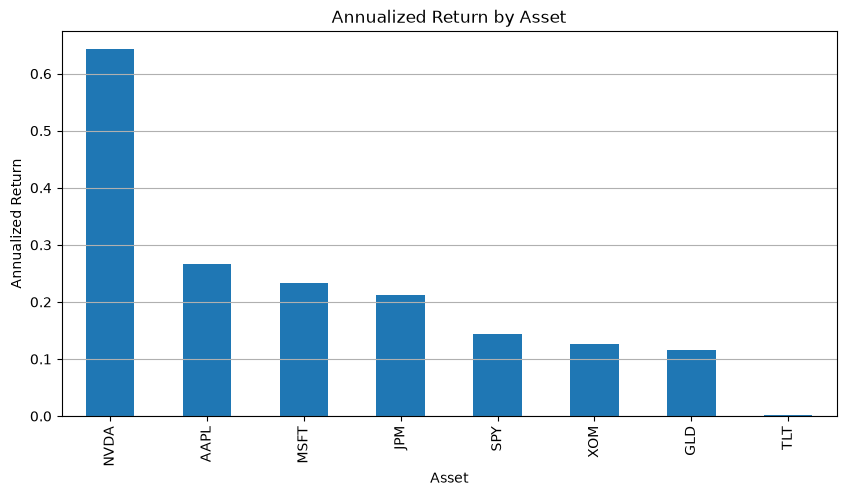

In [11]:
annualized_return.plot(kind="bar", figsize=(10, 5))
plt.title("Annualized Return by Asset")
plt.ylabel("Annualized Return")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 4. CAGR

CAGR measures the compound annual growth rate of each asset over the full period. Unlike the arithmetic annualized return, CAGR reflects the actual compounded growth from the initial price to the final price.

In [12]:
cagr = compute_cagr(prices).sort_values(ascending=False)

cagr

NVDA    0.691104
AAPL    0.251007
MSFT    0.216411
JPM     0.191829
SPY     0.135702
GLD     0.107596
XOM     0.091347
TLT    -0.009308
dtype: float64

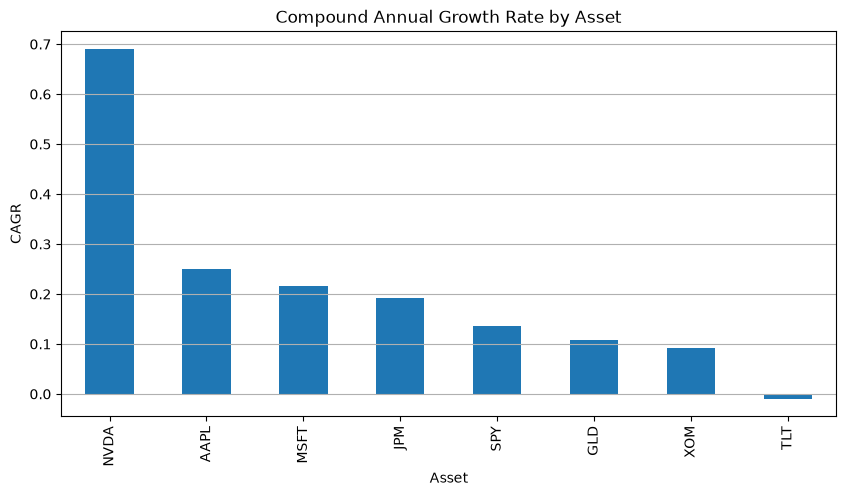

In [13]:
cagr.plot(kind="bar", figsize=(10, 5))
plt.title("Compound Annual Growth Rate by Asset")
plt.ylabel("CAGR")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 5. Annualized Volatility

Volatility measures the dispersion of daily returns. In this notebook, daily volatility is annualized by multiplying it by the square root of 252.

Higher volatility means larger fluctuations and greater uncertainty.

In [14]:
annualized_volatility = compute_annualized_volatility(returns).sort_values(ascending=False)

annualized_volatility

NVDA    0.482332
AAPL    0.287301
XOM     0.275223
MSFT    0.272416
JPM     0.270027
SPY     0.176204
GLD     0.160854
TLT     0.148169
dtype: float64

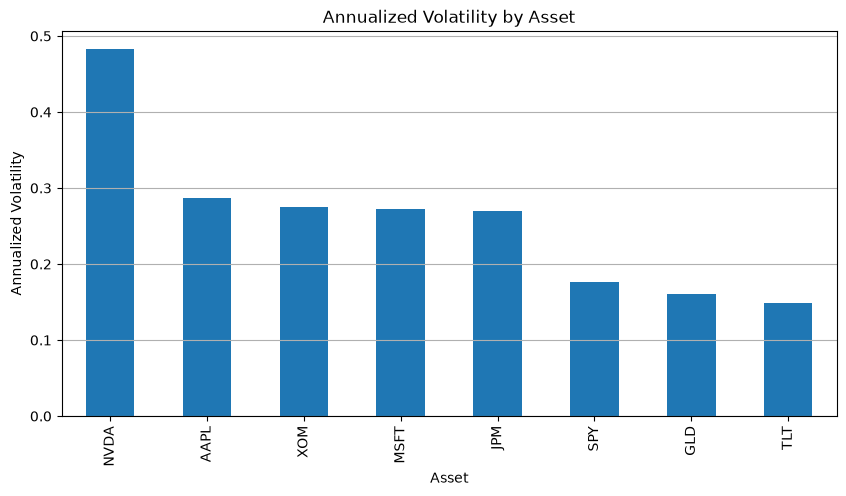

In [15]:
annualized_volatility.plot(kind="bar", figsize=(10, 5))
plt.title("Annualized Volatility by Asset")
plt.ylabel("Annualized Volatility")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 6. Cumulative Returns

Cumulative returns show the growth of one monetary unit invested in each asset at the beginning of the period.

In [16]:
cumulative_returns = compute_cumulative_returns(returns)

cumulative_returns.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-05,0.971828,1.015077,0.968955,0.990804,0.983109,0.981940,1.015708,0.972638
2015-01-06,0.971920,1.026648,0.943831,0.976262,0.953303,0.972692,1.034008,0.967467
2015-01-07,0.985548,1.020600,0.945271,0.988665,0.950819,0.984813,1.031966,0.977270
2015-01-08,1.023415,1.016304,0.966394,1.017750,0.986587,1.002288,1.018300,0.993537
2015-01-09,1.024513,1.027875,0.949592,1.009196,0.990561,0.994256,1.029453,0.992136


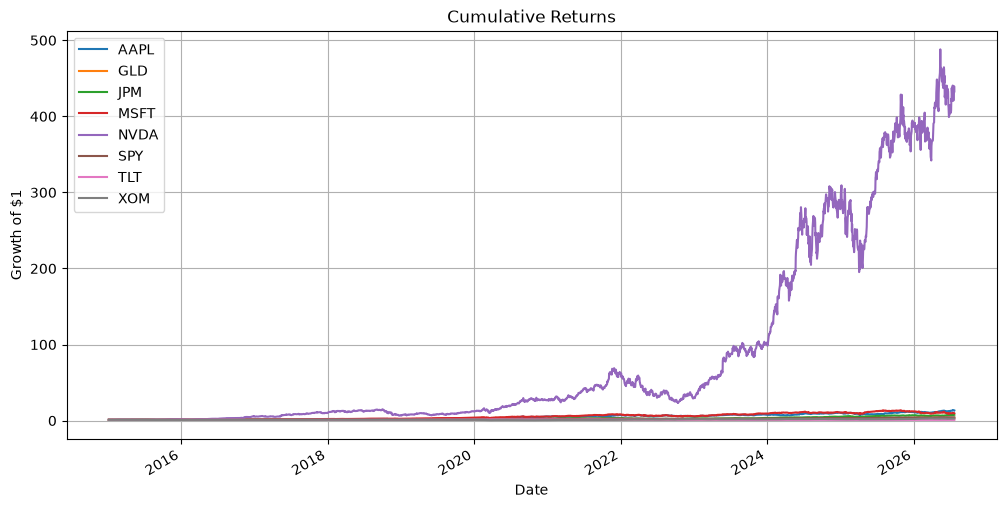

In [17]:
cumulative_returns.plot(figsize=(12, 6))
plt.title("Cumulative Returns")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.grid(True)
plt.show()

## 7. Drawdown Analysis

Drawdown measures the percentage decline from a previous peak. It is important because it shows the losses an investor would have experienced during the period.

In [18]:
drawdowns = compute_drawdowns(returns)

drawdowns.head()

,AAPL,GLD,JPM,MSFT,NVDA,SPY,TLT,XOM
Date,,,,,,,,
2015-01-05,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2015-01-06,0.0,0.000000,-0.025929,-0.014677,-0.030318,-0.009419,0.000000,-0.005316
2015-01-07,0.0,-0.005891,-0.024443,-0.002158,-0.032845,0.000000,-0.001975,0.000000
2015-01-08,0.0,-0.010075,-0.002643,0.000000,0.000000,0.000000,-0.015192,0.000000
2015-01-09,0.0,0.000000,-0.019983,-0.008405,0.000000,-0.008013,-0.004405,-0.001410


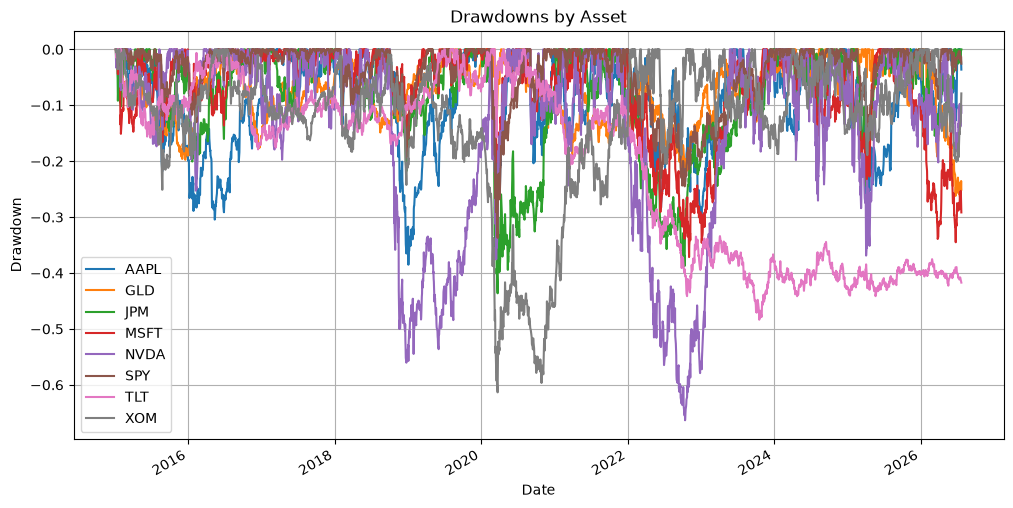

In [19]:
drawdowns.plot(figsize=(12, 6))
plt.title("Drawdowns by Asset")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.grid(True)
plt.show()

## 8. Maximum Drawdown

Maximum Drawdown is the worst peak-to-trough loss during the analysed period.

In [20]:
max_drawdown = compute_max_drawdown(returns).sort_values()

max_drawdown

NVDA   -0.663351
XOM    -0.613425
TLT    -0.483512
JPM    -0.436265
AAPL   -0.385159
MSFT   -0.371485
SPY    -0.337173
GLD    -0.264045
dtype: float64

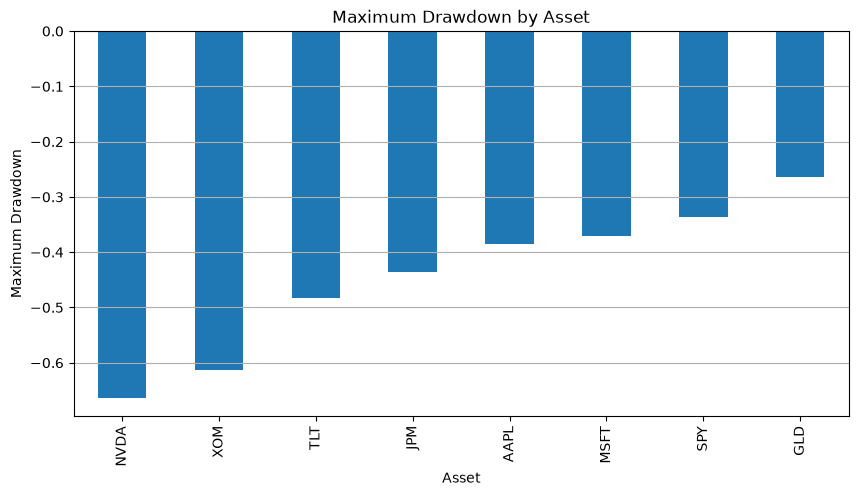

In [21]:
max_drawdown.plot(kind="bar", figsize=(10, 5))
plt.title("Maximum Drawdown by Asset")
plt.ylabel("Maximum Drawdown")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 9. Sharpe Ratio

The Sharpe Ratio measures excess return per unit of total risk.

It is computed as:

Sharpe Ratio = (Annualized Return - Risk-Free Rate) / Annualized Volatility

A higher Sharpe Ratio indicates better return adjusted for volatility.

In [22]:
sharpe_ratio = compute_sharpe_ratio(returns).sort_values(ascending=False)

sharpe_ratio

NVDA    1.290635
AAPL    0.855689
MSFT    0.783962
JPM     0.712445
SPY     0.699046
GLD     0.593420
XOM     0.383477
TLT    -0.124217
dtype: float64

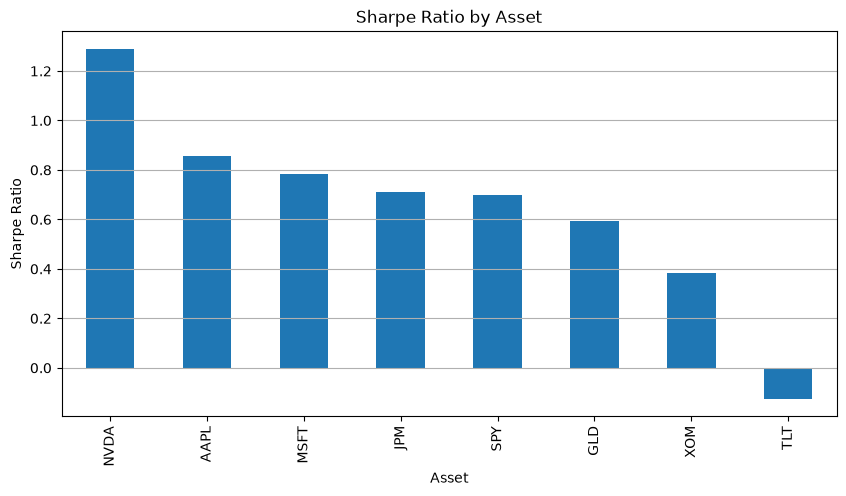

In [23]:
sharpe_ratio.plot(kind="bar", figsize=(10, 5))
plt.title("Sharpe Ratio by Asset")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 10. Sortino Ratio

The Sortino Ratio is similar to the Sharpe Ratio, but it only penalizes downside volatility.

This is useful because investors are usually more concerned about negative deviations than positive ones.

In [24]:
sortino_ratio = compute_sortino_ratio(returns).sort_values(ascending=False)

sortino_ratio

NVDA    1.913406
AAPL    1.183934
MSFT    1.077831
JPM     0.969313
SPY     0.857827
GLD     0.797753
XOM     0.539056
TLT    -0.187425
dtype: float64

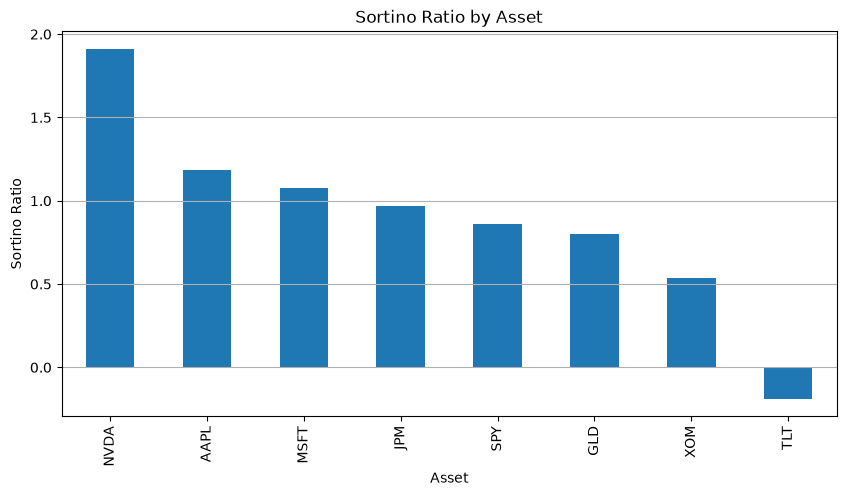

In [25]:
sortino_ratio.plot(kind="bar", figsize=(10, 5))
plt.title("Sortino Ratio by Asset")
plt.ylabel("Sortino Ratio")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 11. Historical Value at Risk

Historical VaR estimates the loss threshold at a given confidence level.

A 95% daily VaR answers the question:

"What daily loss should not be exceeded in 95% of historical observations?"

In [26]:
historical_var = compute_historical_var(returns, confidence_level=0.95).sort_values(ascending=False)

historical_var

NVDA    0.044188
AAPL    0.027139
MSFT    0.026588
XOM     0.025969
JPM     0.025253
SPY     0.016585
GLD     0.015542
TLT     0.014829
Name: 0.050000000000000044, dtype: float64

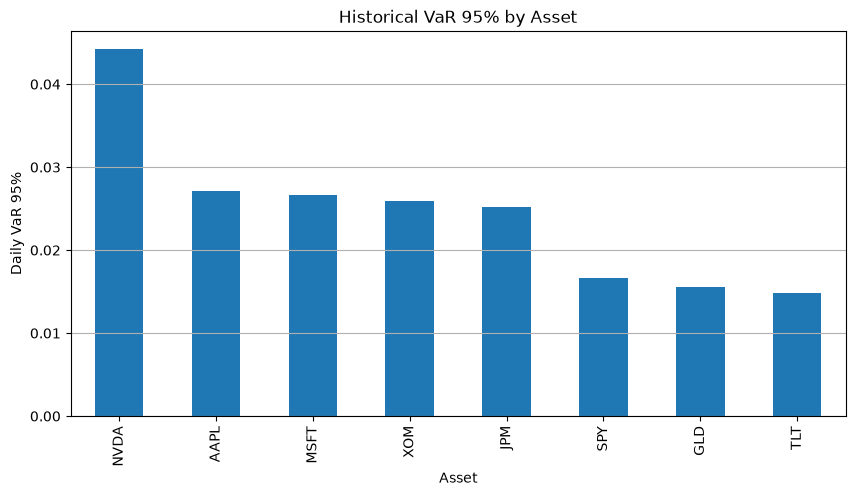

In [27]:
historical_var.plot(kind="bar", figsize=(10, 5))
plt.title("Historical VaR 95% by Asset")
plt.ylabel("Daily VaR 95%")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 12. Historical Conditional Value at Risk

CVaR measures the average loss beyond the VaR threshold.

While VaR tells us where the extreme-loss region starts, CVaR tells us how severe losses are inside that region.

In [28]:
historical_cvar = compute_historical_cvar(returns, confidence_level=0.95).sort_values(ascending=False)

historical_cvar

NVDA    0.064877
AAPL    0.041145
XOM     0.039559
MSFT    0.038797
JPM     0.038434
SPY     0.026758
GLD     0.023489
TLT     0.020261
dtype: float64

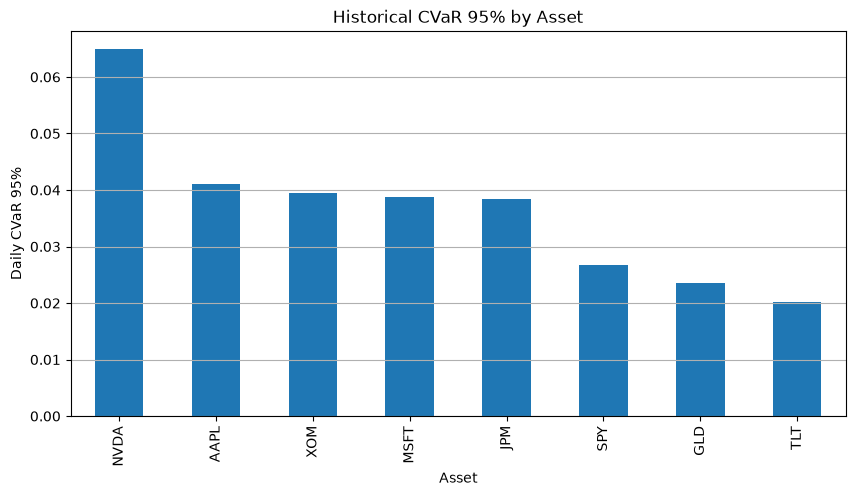

In [29]:
historical_cvar.plot(kind="bar", figsize=(10, 5))
plt.title("Historical CVaR 95% by Asset")
plt.ylabel("Daily CVaR 95%")
plt.xlabel("Asset")
plt.grid(axis="y")
plt.show()

## 13. Risk and Return Rankings

The following rankings help compare assets across return, risk and risk-adjusted performance.

In [30]:
risk_summary.sort_values("CAGR", ascending=False)

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
NVDA,0.642515,0.691104,0.482332,-0.663351,1.290635,1.913406,0.044188,0.064877
AAPL,0.265841,0.251007,0.287301,-0.385159,0.855689,1.183934,0.027139,0.041145
MSFT,0.233564,0.216411,0.272416,-0.371485,0.783962,1.077831,0.026588,0.038797
JPM,0.212380,0.191829,0.270027,-0.436265,0.712445,0.969313,0.025253,0.038434
SPY,0.143175,0.135702,0.176204,-0.337173,0.699046,0.857827,0.016585,0.026758
GLD,0.115454,0.107596,0.160854,-0.264045,0.593420,0.797753,0.015542,0.023489
XOM,0.125542,0.091347,0.275223,-0.613425,0.383477,0.539056,0.025969,0.039559
TLT,0.001595,-0.009308,0.148169,-0.483512,-0.124217,-0.187425,0.014829,0.020261


In [31]:
risk_summary.sort_values("Annualized Volatility", ascending=False)

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
NVDA,0.642515,0.691104,0.482332,-0.663351,1.290635,1.913406,0.044188,0.064877
AAPL,0.265841,0.251007,0.287301,-0.385159,0.855689,1.183934,0.027139,0.041145
XOM,0.125542,0.091347,0.275223,-0.613425,0.383477,0.539056,0.025969,0.039559
MSFT,0.233564,0.216411,0.272416,-0.371485,0.783962,1.077831,0.026588,0.038797
JPM,0.212380,0.191829,0.270027,-0.436265,0.712445,0.969313,0.025253,0.038434
SPY,0.143175,0.135702,0.176204,-0.337173,0.699046,0.857827,0.016585,0.026758
GLD,0.115454,0.107596,0.160854,-0.264045,0.593420,0.797753,0.015542,0.023489
TLT,0.001595,-0.009308,0.148169,-0.483512,-0.124217,-0.187425,0.014829,0.020261


In [32]:
risk_summary.sort_values("Sharpe Ratio", ascending=False)

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
NVDA,0.642515,0.691104,0.482332,-0.663351,1.290635,1.913406,0.044188,0.064877
AAPL,0.265841,0.251007,0.287301,-0.385159,0.855689,1.183934,0.027139,0.041145
MSFT,0.233564,0.216411,0.272416,-0.371485,0.783962,1.077831,0.026588,0.038797
JPM,0.212380,0.191829,0.270027,-0.436265,0.712445,0.969313,0.025253,0.038434
SPY,0.143175,0.135702,0.176204,-0.337173,0.699046,0.857827,0.016585,0.026758
GLD,0.115454,0.107596,0.160854,-0.264045,0.593420,0.797753,0.015542,0.023489
XOM,0.125542,0.091347,0.275223,-0.613425,0.383477,0.539056,0.025969,0.039559
TLT,0.001595,-0.009308,0.148169,-0.483512,-0.124217,-0.187425,0.014829,0.020261


In [33]:
risk_summary.sort_values("Maximum Drawdown")

,Annualized Return,CAGR,Annualized Volatility,Maximum Drawdown,Sharpe Ratio,Sortino Ratio,Historical VaR 95%,Historical CVaR 95%
NVDA,0.642515,0.691104,0.482332,-0.663351,1.290635,1.913406,0.044188,0.064877
XOM,0.125542,0.091347,0.275223,-0.613425,0.383477,0.539056,0.025969,0.039559
TLT,0.001595,-0.009308,0.148169,-0.483512,-0.124217,-0.187425,0.014829,0.020261
JPM,0.212380,0.191829,0.270027,-0.436265,0.712445,0.969313,0.025253,0.038434
AAPL,0.265841,0.251007,0.287301,-0.385159,0.855689,1.183934,0.027139,0.041145
MSFT,0.233564,0.216411,0.272416,-0.371485,0.783962,1.077831,0.026588,0.038797
SPY,0.143175,0.135702,0.176204,-0.337173,0.699046,0.857827,0.016585,0.026758
GLD,0.115454,0.107596,0.160854,-0.264045,0.593420,0.797753,0.015542,0.023489


In [34]:
output_path = Path("../data/processed/risk_summary_notebook.csv")
risk_summary.to_csv(output_path)

output_path

PosixPath('../data/processed/risk_summary_notebook.csv')

## Preliminary Conclusions

This notebook extends the initial market data pipeline by computing formal cross-asset risk and return metrics.

The analysis shows that assets with higher historical growth may also present higher volatility and deeper drawdowns. For this reason, cumulative performance alone is not sufficient to evaluate an investment decision.

Risk-adjusted metrics such as the Sharpe Ratio and Sortino Ratio provide a more complete view because they compare returns with the amount of risk taken. Drawdown analysis adds another important perspective by showing the worst historical losses from previous peaks.

Historical VaR and CVaR estimate downside risk under adverse market conditions. VaR identifies a loss threshold, while CVaR estimates the average loss beyond that threshold.

Overall, this phase moves the project from descriptive market exploration toward quantitative decision analysis. The next step will be to use these metrics to analyse portfolios, compare allocations and evaluate diversification effects.